In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
V0 = 1e-10
v0 = V0 / 24 * np.pi * np.pi
beta = 0.01
deltaPhiWell = 2 * (2 / 3 * v0 / beta) ** (1 / 3)
phi0 = 0.5 * deltaPhiWell + 0.3 / np.sqrt(beta)

def infPotFunc(phi):
    x = phi - phi0
    return float(V0 * (1 + beta * x * x * x))

def infPotDerivFunc(phi):
    x = phi - phi0
    return float(3 * V0 * beta * x * x)

def infPotDeriv2Func(phi):
    x = phi - phi0
    return float(6 * V0 * beta * x)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

upperBound = phi0 + deltaPhiWell
lowerBound = phi0 - deltaPhiWell
nGrid = 4096  

In [3]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

c:\Users\koich\Desktop\Code\StochasticInflationDiffOpEigen\InfAdjFPFiniteDiffApp.py:121: RuntimeWarning: invalid value encountered in double_scalars
  slowrollEta = np.abs(vDers.T @ vDer2AtGrids[:,:,ig] @ vDers / vAtGrids[ig] / np.sum(vDers ** 2))


In [4]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [5]:
fpFinDiff_DirDir[:10,:10]

array([[ 0.48494215, -0.22610116,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.22610116,  0.48487836, -0.22610116,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.22610116,  0.48481466, -0.22610116,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.22610116,  0.48475106, -0.22610116,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.22610116,  0.48468755,
        -0.22610116,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.22610116,
         0.48462413, -0.22610116,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.22610116,  0.48456081, -0.22610116

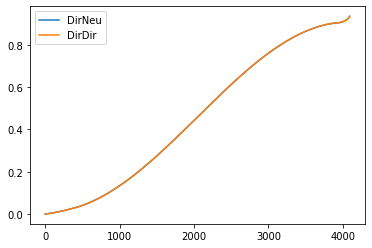

In [6]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

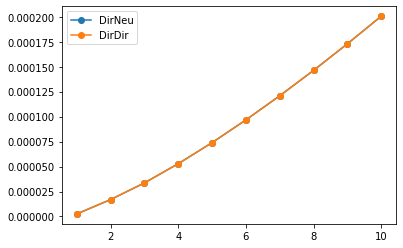

In [7]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 11), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

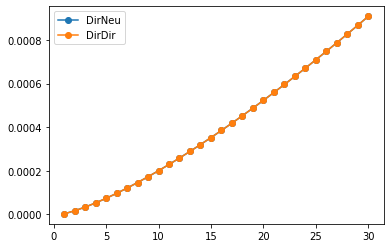

In [8]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirDir[:30], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [9]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[2.56485041e-06 1.69238408e-05 3.36399281e-05 5.28290467e-05
 7.39400658e-05 9.66774641e-05 1.20837051e-04 1.46268747e-04
 1.72856677e-04 2.00508186e-04]
[2.56485041e-06 1.69238409e-05 3.36399283e-05 5.28290470e-05
 7.39400663e-05 9.66774650e-05 1.20837053e-04 1.46268749e-04
 1.72856680e-04 2.00508190e-04]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

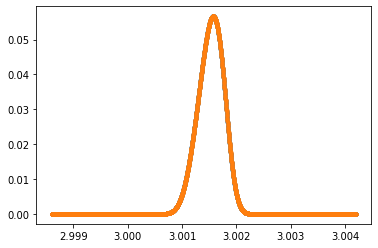

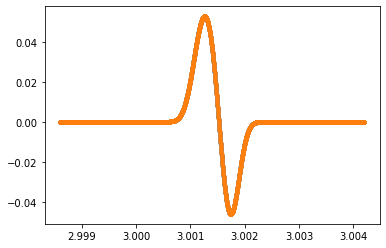

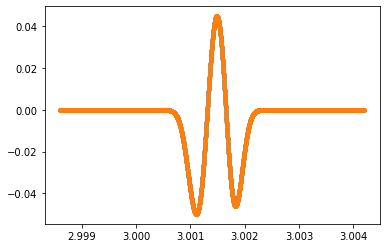

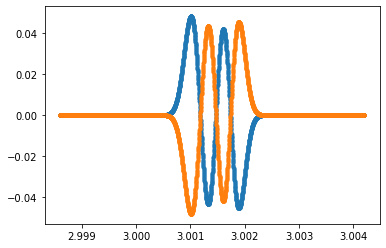

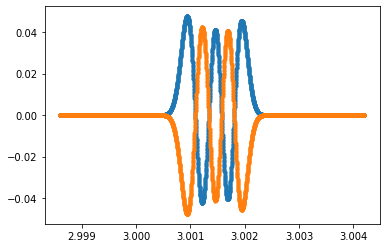

In [10]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))

ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [11]:
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

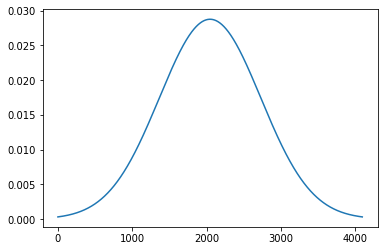

In [12]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

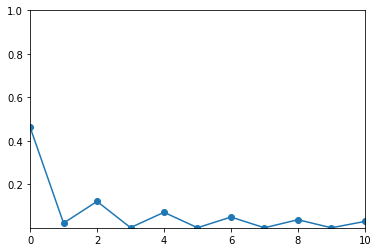

In [13]:
# 各固有ベクトルの寄与度
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort_DirDir]

ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

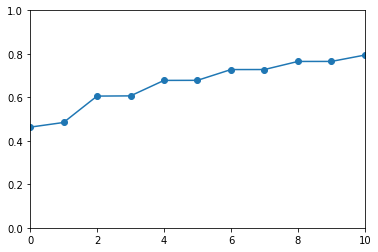

In [14]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()

変換する前の元々の微分演算子を離散化して固有値を求める

In [15]:
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator

In [16]:
fpFinDiff_DirNeu_OriOp = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu_OriOp, eigVecs_DirNeu_OriOp = np.linalg.eig(fpFinDiff_DirNeu_OriOp)
eigVecsSort_DirNeu_OriOp = eigVecs_DirNeu_OriOp.T[np.argsort(eigVals_DirNeu_OriOp)]
eigValsSort_DirNeu_OriOp = np.sort(eigVals_DirNeu_OriOp)

In [17]:
fpFinDiff_DirDir_OriOp = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir_OriOp, eigVecs_DirDir_OriOp = np.linalg.eig(fpFinDiff_DirDir_OriOp)
eigVecsSort_DirDir_OriOp = eigVecs_DirDir_OriOp.T[np.argsort(eigVals_DirDir_OriOp)]
eigValsSort_DirDir_OriOp = np.sort(eigVals_DirDir_OriOp)

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


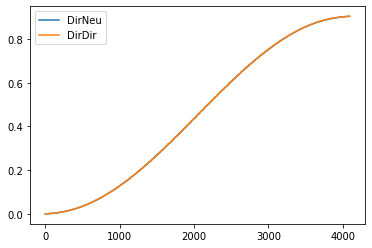

In [18]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu_OriOp, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir_OriOp, label = "DirDir")
plt.legend()
plt.show()

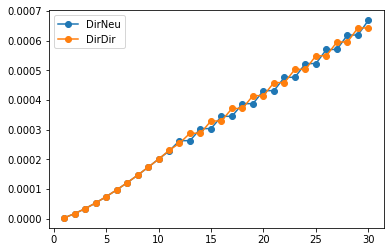

In [19]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu_OriOp[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirDir_OriOp[:30], marker='o', label = "DirDir")
plt.legend()
plt.show()

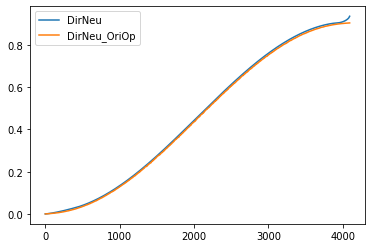

In [24]:
# 変換前後の微分演算子の固有値の比較（下端ディリクレ・上端ノイマン）
# 大体合ってるっぽいけど...
ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirNeu_OriOp, label = "DirNeu_OriOp")
plt.legend()
plt.show()

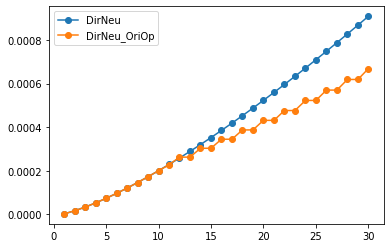

In [25]:
# 変換前後の微分演算子の固有値の比較（下端ディリクレ・上端ノイマン）
# 第10固有値くらいまでは合うがその後合わない...
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirNeu_OriOp[:30], marker='o', label = "DirNeu_OriOp")
plt.legend()
plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


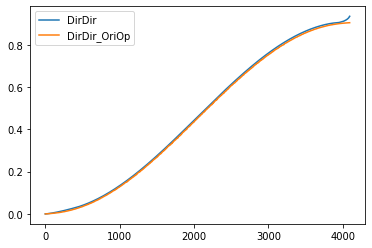

In [26]:
# 変換前後の微分演算子の固有値の比較（上下端ディリクレ）
# 大体合ってるっぽいけど...
ax = plt.gca()
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.plot(nMode, eigValsSort_DirDir_OriOp, label = "DirDir_OriOp")
plt.legend()
plt.show()

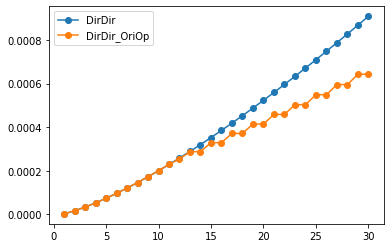

In [27]:
# 変換前後の微分演算子の固有値の比較（上下端ディリクレ）
# 第10固有値くらいまでは合うがその後合わない...
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirDir[:30], marker='o', label = "DirDir")
plt.plot(np.arange(1, 31), eigValsSort_DirDir_OriOp[:30], marker='o', label = "DirDir_OriOp")
plt.legend()
plt.show()

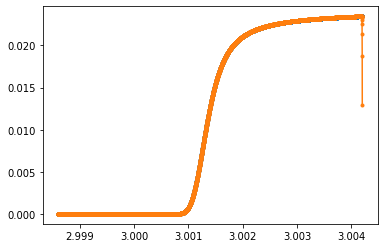

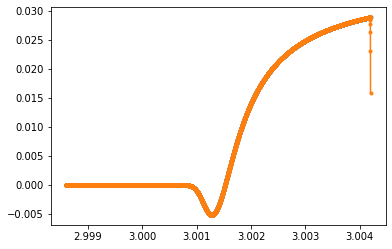

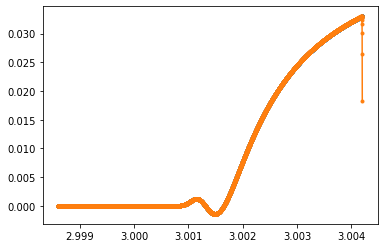

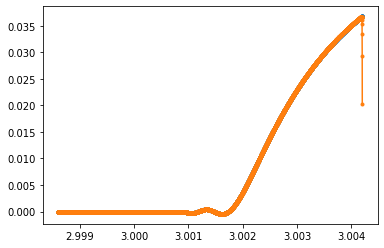

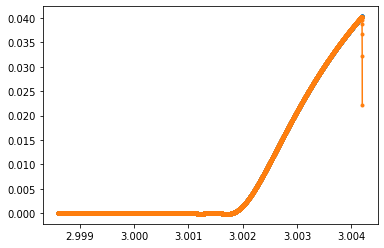

In [23]:
# 固有関数のプロット（変換前微分演算子）
# ディリクレとノイマンは-1倍を除いて一致するが、ディリクレの場合に上端で急に0に行くのは良いんだろうか...
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sgn = [-1, -1, 1, 1, -1]

ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu_OriOp[iEig],marker='.', label="DirNeu")
    plt.plot(grids, sgn[iEig] * eigVecsSort_DirDir_OriOp[iEig],marker='.', label="DirDir")
    plt.show()

領域を広げてみる

In [28]:
upperBound_wide = phi0 + deltaPhiWell * 5
lowerBound_wide = phi0 - deltaPhiWell * 5

In [29]:
fpFinDiff_DirNeu_wide = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound_wide],
    [lowerBound_wide],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu_wide, eigVecs_DirNeu_wide = np.linalg.eig(fpFinDiff_DirNeu_wide)
eigVecsSort_DirNeu_wide = eigVecs_DirNeu_wide.T[np.argsort(eigVals_DirNeu_wide)]
eigValsSort_DirNeu_wide = np.sort(eigVals_DirNeu_wide)

In [30]:
fpFinDiff_DirDir_wide = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound_wide],
    [lowerBound_wide],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir_wide, eigVecs_DirDir_wide = np.linalg.eig(fpFinDiff_DirDir_wide)
eigVecsSort_DirDir_wide = eigVecs_DirDir_wide.T[np.argsort(eigVals_DirDir_wide)]
eigValsSort_DirDir_wide = np.sort(eigVals_DirDir_wide)

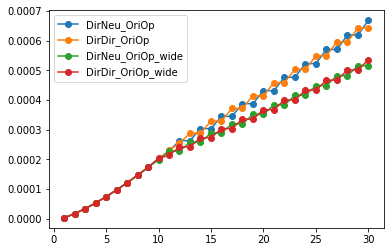

In [39]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu_OriOp[:30], marker='o', label = "DirNeu_OriOp")
plt.plot(np.arange(1, 31), eigValsSort_DirDir_OriOp[:30], marker='o', label = "DirDir_OriOp")
plt.plot(np.arange(1, 31), eigValsSort_DirNeu_wide[:30], marker='o', label = "DirNeu_OriOp_wide")
plt.plot(np.arange(1, 31), eigValsSort_DirDir_wide[:30], marker='o', label = "DirDir_OriOp_wide")
plt.legend()
plt.show()

固有関数の形状は境界の位置が違うとかなり違う...

なのになぜか小さい固有値は変化しない...

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


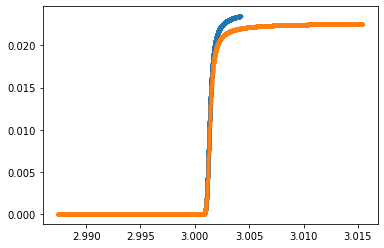

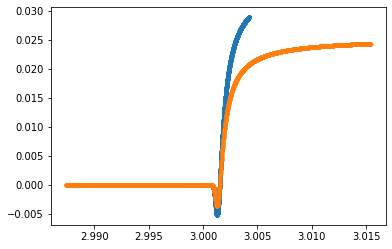

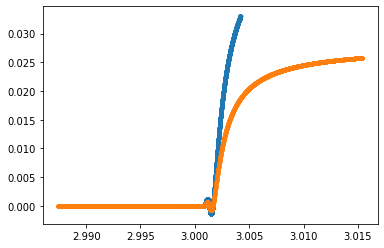

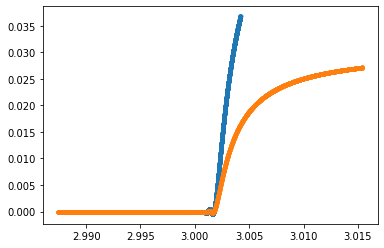

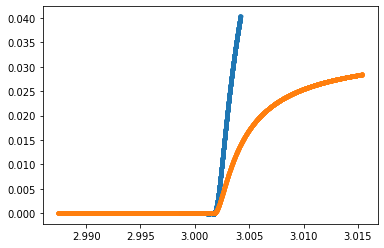

In [35]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
grids_wide = np.flip(np.linspace(upperBound_wide, lowerBound_wide, nGrid, endpoint=False))

ax = plt.gca()

# 符号調整
sgn =[-1, 1, -1, -1, -1]

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu_OriOp[iEig],marker='.', label="DirNeu")
    plt.plot(grids_wide, sgn[iEig] * eigVecsSort_DirNeu_wide[iEig],marker='.', label="DirNeu_wide")
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


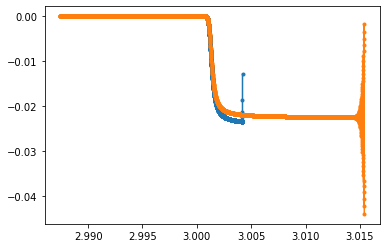

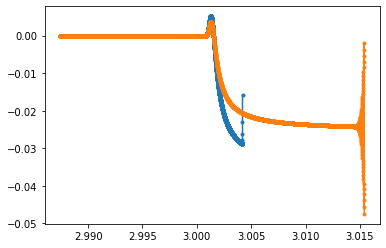

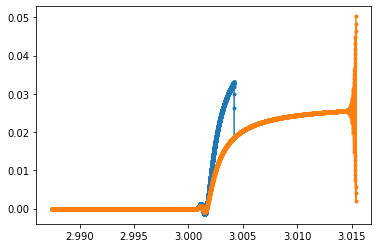

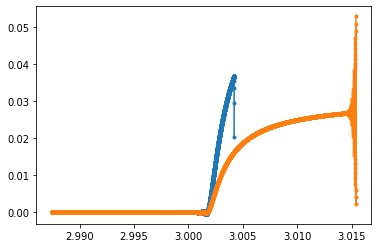

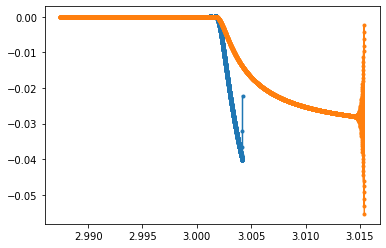

In [36]:
ax = plt.gca()

# 符号調整
sgn =[1, 1, -1, -1, 1]

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirDir_OriOp[iEig],marker='.', label="DirDir")
    plt.plot(grids_wide, sgn[iEig] * eigVecsSort_DirDir_wide[iEig],marker='.', label="DirDir_wide")
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


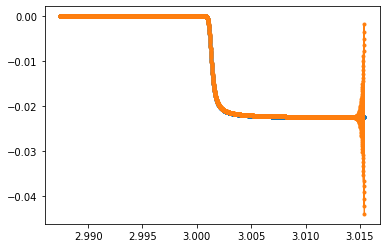

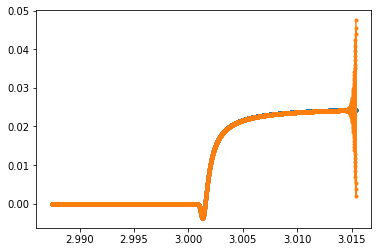

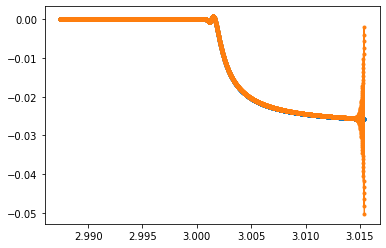

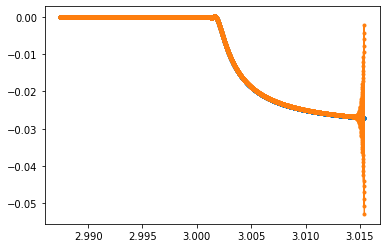

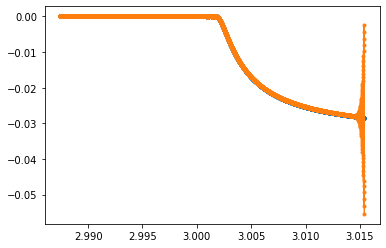

In [37]:
ax = plt.gca()

sgn = [1, -1, 1, 1, 1]

for iEig in range(5):
    plt.plot(grids_wide, eigVecsSort_DirNeu_wide[iEig],marker='.', label="DirNeu_wide")
    plt.plot(grids_wide, sgn[iEig] * eigVecsSort_DirDir_wide[iEig],marker='.', label="DirDir_wide")
    plt.show()